<a href="https://colab.research.google.com/github/dbswodyd1/data-structure-2026/blob/master/Lec07_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 09: Searching

## 1. What is Searching?

In [2]:
15 in [3,5,2,4,1]

False

In [3]:
3 in [3,5,2,4,1]

True

## 2. The Sequential Search

In [4]:
def sequential_search(a_list, item):
    pos = 0
    found = False

    while pos < len(a_list) and not found:
        if a_list[pos] == item:
            found = True
        else:
            pos = pos+1

    return found

In [5]:
test_list = [1, 4, 32, 10, 11, 19, 42, 13, 0, 12, 102]

In [6]:
print(sequential_search(test_list, 3))

False


In [7]:
print(sequential_search(test_list, 13))

True


## 3. The Ordered Sequential Search

In [8]:
def ordered_sequential_search(a_list, item):
    pos = 0
    found = False
    stop = False

    while pos < len(a_list) and not found and not stop:
        if a_list[pos] == item:
            found = True
        else:
            if a_list[pos] > item:
                stop = True
            else:
                pos = pos+1

    return found

In [9]:
#test_list = [1, 2, 32, 8, 17, 19, 42, 13, 0]
test_list = [0, 1, 2, 8, 13, 17, 19, 32, 42]

In [10]:
print(ordered_sequential_search(test_list, 3))

False


In [11]:
print(ordered_sequential_search(test_list, 13))

True


## 4. The Binary Search

In [12]:
def binary_search(a_list, item):
    first = 0
    last = len(a_list) - 1
    found = False

    while first <= last and not found:
        midpoint = (first + last) // 2
        if a_list[midpoint] == item:
            found = True
        else:
            if item < a_list[midpoint]:
                last = midpoint - 1
            else:
                first = midpoint + 1
    return found

In [13]:
test_list = [0, 1, 2, 8, 13, 17, 19, 32, 42]

In [14]:
print(binary_search(test_list, 3))

False


In [15]:
print(binary_search(test_list, 13))

True


### 4.1 Implementation using Recursion

In [16]:
def binary_search(a_list, item):
    if len(a_list) == 0:
        return False
    else:
        print('lo, hi = ', (a_list[0], a_list[-1]))
        midpoint = len(a_list) // 2

    if a_list[midpoint] == item:
        return True
    else:
        if item < a_list[midpoint]:
            return binary_search(a_list[:midpoint], item)
        else:
            return binary_search(a_list[midpoint + 1:],item)

In [17]:
test_list = [0, 1, 2, 8, 13, 17, 19, 32, 42]

In [18]:
print(binary_search(test_list, 3))

lo, hi =  (0, 42)
lo, hi =  (0, 8)
lo, hi =  (8, 8)
False


In [19]:
print(binary_search(test_list, 13))

lo, hi =  (0, 42)
True


In [20]:
binary_search(list(range(100)), 20)

lo, hi =  (0, 99)
lo, hi =  (0, 49)
lo, hi =  (0, 24)
lo, hi =  (13, 24)
lo, hi =  (20, 24)
lo, hi =  (20, 21)
lo, hi =  (20, 20)


True

In [21]:
binary_search(list(range(100)), -1)

lo, hi =  (0, 99)
lo, hi =  (0, 49)
lo, hi =  (0, 24)
lo, hi =  (0, 11)
lo, hi =  (0, 5)
lo, hi =  (0, 2)
lo, hi =  (0, 0)


False

In [22]:
binary_search(list(range(100)), 50.5)

lo, hi =  (0, 99)
lo, hi =  (51, 99)
lo, hi =  (51, 74)
lo, hi =  (51, 62)
lo, hi =  (51, 56)
lo, hi =  (51, 53)
lo, hi =  (51, 51)


False

## 5. Sequential Search Vs. Binary Search

In [23]:
import timeit

In [24]:
import matplotlib.pyplot as plt

In [25]:
def time_seq_search(size):
    return timeit.timeit('ordered_sequential_search(lst, random.randrange({}))'.format(size), # interpolate size into randrange
                         'import random ; from __main__ import ordered_sequential_search ;'
                         'lst = [x for x in range({})]'.format(size), # interpolate size into list range
                         number=50)

In [26]:
def time_bin_search(size):
    return timeit.timeit('binary_search(lst, random.randrange({}))'.format(size), # interpolate size into randrange
                         'import random ; from __main__ import binary_search ;'
                         'lst = [x for x in range({})]'.format(size), # interpolate size into list range
                         number=50)

In [27]:
seq_search_timings = [time_seq_search(n)
                      for n in range(10, 10000, 100)]

In [28]:
seq_search_timings

[9.918699993249902e-05,
 0.00043470399987199926,
 0.0009963259999494767,
 0.0011807020000560442,
 0.0010596480001368036,
 0.0014375519999703101,
 0.0017414820001704356,
 0.0018708119998791517,
 0.0027665529999012506,
 0.002297327999940535,
 0.002811062000091624,
 0.003207434000159992,
 0.0030259080001542316,
 0.0034972910000306,
 0.00422714299998006,
 0.005023424999990311,
 0.0055627560000175436,
 0.005753177999849868,
 0.006848482999885164,
 0.005670096000130798,
 0.0051235859998541855,
 0.006221917999937432,
 0.009208153999907154,
 0.0067141940000965405,
 0.009327281999958359,
 0.00784638699997231,
 0.008533514999953695,
 0.007633694999867657,
 0.00954575300011129,
 0.007512488999964262,
 0.008946835999950054,
 0.011131218000173249,
 0.009648263999906703,
 0.01394041699995796,
 0.011319138000089879,
 0.009984462000147687,
 0.011108085000159917,
 0.009026618999996572,
 0.010985657999981413,
 0.01176055699988865,
 0.010940407999896706,
 0.012876770000048054,
 0.012222723000149927,
 0.0

In [29]:
bin_search_timings = [time_bin_search(n)
                      for n in range(10, 10000, 100)]

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
lo, hi =  (3417, 3700)
lo, hi =  (3560, 3700)
lo, hi =  (3631, 3700)
lo, hi =  (3631, 3665)
lo, hi =  (3649, 3665)
lo, hi =  (3658, 3665)
lo, hi =  (3663, 3665)
lo, hi =  (0, 9109)
lo, hi =  (0, 4554)
lo, hi =  (0, 2276)
lo, hi =  (1139, 2276)
lo, hi =  (1139, 1707)
lo, hi =  (1424, 1707)
lo, hi =  (1424, 1565)
lo, hi =  (1496, 1565)
lo, hi =  (1496, 1530)
lo, hi =  (1514, 1530)
lo, hi =  (1523, 1530)
lo, hi =  (1523, 1526)
lo, hi =  (0, 9109)
lo, hi =  (0, 4554)
lo, hi =  (2278, 4554)
lo, hi =  (2278, 3415)
lo, hi =  (2848, 3415)
lo, hi =  (3133, 3415)
lo, hi =  (3275, 3415)
lo, hi =  (3346, 3415)
lo, hi =  (3382, 3415)
lo, hi =  (3400, 3415)
lo, hi =  (3400, 3407)
lo, hi =  (3405, 3407)
lo, hi =  (3405, 3405)
lo, hi =  (0, 9109)
lo, hi =  (0, 4554)
lo, hi =  (2278, 4554)
lo, hi =  (2278, 3415)
lo, hi =  (2848, 3415)
lo, hi =  (2848, 3131)
lo, hi =  (2848, 2989)
lo, hi =  (2920, 2989)
lo, hi =  (2920, 2954)
lo, hi =  (2938, 2954)
lo, hi =  (2947, 29

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5358/91752323.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Sequential Search $\mathcal{O}(n)$', 'Binary Search $\mathcal{O}(\log n)$'],
/tmp/ipykernel_5358/91752323.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Sequential Search $\mathcal{O}(n)$', 'Binary Search $\mathcal{O}(\log n)$'],


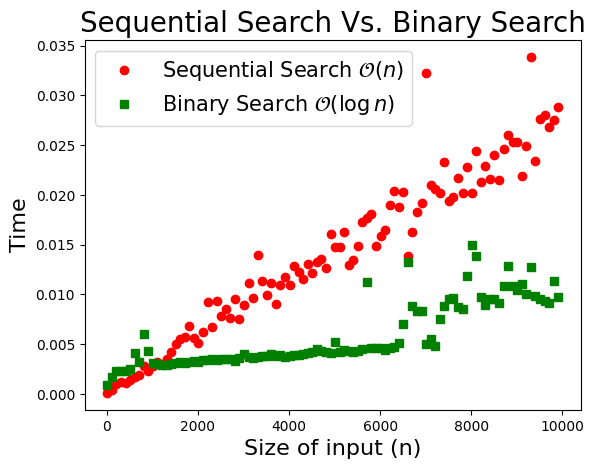

In [30]:
plt.xlabel('Size of input (n)', fontsize=16)
plt.ylabel('Time', fontsize=16)
plt.title('Sequential Search Vs. Binary Search', fontsize = 20)
plt.plot(range(10, 10000, 100), seq_search_timings, 'ro')
plt.plot(range(10, 10000, 100), bin_search_timings, 'gs')
plt.legend(['Sequential Search $\mathcal{O}(n)$', 'Binary Search $\mathcal{O}(\log n)$'],
             loc='best', fontsize=15);
plt.show()

- ## $\mathcal{O}(n)$ vs. $\mathcal{O}(\log n)$

## 6. Hashing

1. Multiplication Method
2. Folding method
3. Mid-square method

In [31]:
import math
# 1. multiplication method
def multiplication_hash(k, m, A=(math.sqrt(5)-1/2)):
  frac = k * A % 1
  return math.floor(m * frac)

# 2. folding method
def folding_hash(k, m, group=2):
  base = 10 ** group
  s = 0
  while k > 0:
    s += k % base
    k //= base
  return s % m

# 3. Mid-square method
def mid_square_hash(k, m):
  s = k ** 2
  mid = (len(str(s))//2)  # 가운데 위치
  return int(str(s)[mid:mid+2]) % m

In [32]:
m = 16
keys = [123, 125, 61, 151, 1616, 2323, 12415]
print("key | mult | fold | mid")
for k in keys:
  print(f"{k} | {multiplication_hash(k, m)} | {folding_hash(k, m)} | {mid_square_hash(k, m)}")


key | mult | fold | mid
123 | 8 | 8 | 12
125 | 0 | 10 | 14
61 | 14 | 13 | 5
151 | 2 | 4 | 0
1616 | 7 | 0 | 14
2323 | 14 | 14 | 15
12415 | 4 | 8 | 0


Hashing a string

In [33]:
ord('c')

99

In [34]:
ord('a')

97

In [35]:
ord('t')

116

In [36]:
def hash(a_string, table_size):
    sum = 0
    for pos in range(len(a_string)):
        sum = sum + pos*ord(a_string[pos])

    return sum % table_size

In [37]:
hash('dog', 20)

17

In [38]:
class HashTable:
    def __init__(self, size = 11):
        self.size = size
        self.slots = [None] * self.size
        self.data = [None] * self.size

    def put(self, key, data):
        hash_value = self.hash_function(key,len(self.slots))

        if self.slots[hash_value] == None:      # 해당 hash_value 자리가 비어있으면
            self.slots[hash_value] = key
            self.data[hash_value] = data
        else:                                   # 해당 hash_value 자리에 이미 존재하면
            if self.slots[hash_value] == key:   # 같은 Key이면
                self.data[hash_value] = data    # replace
            else:                               # 같은 Key가 아니면 next slot 찾아야 함
                next_slot = self.rehash(hash_value, len(self.slots))    # rehash
                # 비어있지 않고 key랑 다른 경우 반복
                while self.slots[next_slot] != None and self.slots[next_slot] != key:
                    next_slot = self.rehash(next_slot, len(self.slots))

                if self.slots[next_slot] == None:
                    self.slots[next_slot] = key
                    self.data[next_slot] = data
                else:
                    self.data[next_slot] = data # replace

    def hash_function(self, key, size):
        return key % size

    def rehash(self, old_hash, size):
        return (old_hash + 1) % size

    def get(self, key):
        start_slot = self.hash_function(key, len(self.slots))

        data = None
        stop = False
        found = False
        position = start_slot
        while self.slots[position] != None and not found and not stop:
            if self.slots[position] == key:
                found = True
                data = self.data[position]
            else:
                position=self.rehash(position, len(self.slots))
                if position == start_slot:
                    stop = True
        return data

    def __getitem__(self, key):
        return self.get(key)

    def __setitem__(self, key, data):
        self.put(key, data)

In [39]:
h=HashTable()

In [40]:
h[54]="cat"
h[26]="dog"
h[93]="lion"
h[17]="tiger"
h[77]="bird"
h[31]="cow"
h[44]="goat"
h[55]="pig"
h[20]="chicken"

In [41]:
h.slots

[77, 44, 55, 20, 26, 93, 17, None, None, 31, 54]

In [42]:
h.data

['bird',
 'goat',
 'pig',
 'chicken',
 'dog',
 'lion',
 'tiger',
 None,
 None,
 'cow',
 'cat']

In [43]:
h[20]

'chicken'

In [44]:
h[17]

'tiger'

In [45]:
h[20] = 'duck'

In [46]:
h[20]

'duck'

In [47]:
h.data

['bird',
 'goat',
 'pig',
 'duck',
 'dog',
 'lion',
 'tiger',
 None,
 None,
 'cow',
 'cat']

In [48]:
h.put(20, 'deer')

In [49]:
h.data

['bird',
 'goat',
 'pig',
 'deer',
 'dog',
 'lion',
 'tiger',
 None,
 None,
 'cow',
 'cat']

In [50]:
h.put(31, 'monkey')

In [51]:
h.data

['bird',
 'goat',
 'pig',
 'deer',
 'dog',
 'lion',
 'tiger',
 None,
 None,
 'monkey',
 'cat']

In [52]:
print(h[99])

None


## 7. Binary Search Vs. Hashing

In [53]:
def prep_ht(size):
    ht = HashTable(size)
    for x in range(size):
        ht[x] = x
    return ht

In [54]:
def time_bin_search(size):
    return timeit.timeit('binary_search(lst, random.randrange({}))'.format(size), # interpolate size into randrange
                         'import random ; from __main__ import binary_search ;'
                         'lst = [x for x in range({})]'.format(size), # interpolate size into list range
                         number=50)

def time_hash(size):
    return timeit.timeit('ht[random.randrange({})]'.format(size),
                         'import random ; from __main__ import prep_ht ;'
                         'ht = prep_ht({})'.format(size),
                         number=50)

bin_search_timings = [time_bin_search(n)
                      for n in range(10, 10000, 100)]

hash_timings = [time_hash(n)
                for n in range(10, 10000, 100)]

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
lo, hi =  (2278, 2561)
lo, hi =  (2278, 2419)
lo, hi =  (2278, 2348)
lo, hi =  (2314, 2348)
lo, hi =  (2314, 2330)
lo, hi =  (2314, 2321)
lo, hi =  (0, 9109)
lo, hi =  (4556, 9109)
lo, hi =  (4556, 6832)
lo, hi =  (4556, 5693)
lo, hi =  (5126, 5693)
lo, hi =  (5411, 5693)
lo, hi =  (5411, 5551)
lo, hi =  (5482, 5551)
lo, hi =  (5518, 5551)
lo, hi =  (5518, 5534)
lo, hi =  (5527, 5534)
lo, hi =  (5527, 5530)
lo, hi =  (5530, 5530)
lo, hi =  (0, 9109)
lo, hi =  (0, 4554)
lo, hi =  (2278, 4554)
lo, hi =  (2278, 3415)
lo, hi =  (2848, 3415)
lo, hi =  (3133, 3415)
lo, hi =  (3133, 3273)
lo, hi =  (3204, 3273)
lo, hi =  (3204, 3238)
lo, hi =  (3204, 3220)
lo, hi =  (3204, 3211)
lo, hi =  (3204, 3207)
lo, hi =  (3204, 3205)
lo, hi =  (3204, 3204)
lo, hi =  (0, 9109)
lo, hi =  (0, 4554)
lo, hi =  (0, 2276)
lo, hi =  (1139, 2276)
lo, hi =  (1139, 1707)
lo, hi =  (1139, 1422)
lo, hi =  (1282, 1422)
lo, hi =  (1282, 1351)
lo, hi =  (1318, 1351)
lo, hi =  (1336,

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5358/4022237671.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Binary Search $\mathcal{O}(\log n)$', 'Hashing $\mathcal{O}(1)$'],
/tmp/ipykernel_5358/4022237671.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Binary Search $\mathcal{O}(\log n)$', 'Hashing $\mathcal{O}(1)$'],


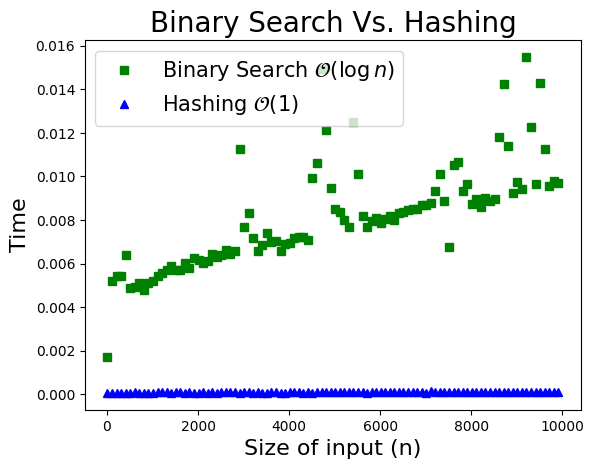

In [55]:
plt.xlabel('Size of input (n)', fontsize=16)
plt.ylabel('Time', fontsize=16)
plt.title('Binary Search Vs. Hashing', fontsize = 20)
plt.plot(range(10, 10000, 100), bin_search_timings, 'gs')
plt.plot(range(10, 10000, 100), hash_timings, 'b^')
plt.legend(['Binary Search $\mathcal{O}(\log n)$', 'Hashing $\mathcal{O}(1)$'],
            loc='best', fontsize=15);
# plt.legend(['Binary Search $\mathcal{O}(\log n)$', 'Hashing $\mathcal{O}(1)$'],
#             loc='best', numpoints=1, fontsize=15);
plt.show()

## $\mathcal{O}(\log n)$ vs. $\mathcal{O}(1)$.